In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

credit_df = pd.read_csv("../data/processed/credit_df_processed.csv")
credit_df.head()


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,1,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,0,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,0,1,1


In [3]:
X = credit_df.drop(columns=['loan_status'])
y = credit_df['loan_status']


In [4]:
with open("../models/random_forest.pkl", "rb") as f:
    rf_clf = pickle.load(f)

In [5]:
sample = X.iloc[[0]]
sample

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,0,0


### Función de análisis de sensibilidad

In [6]:
def sensitivity_analysis(model, X_sample, feature, variations=[-0.2, -0.1, 0, 0.1, 0.2]):
    """
    Análisis de sensibilidad: Varía una feature y mide el cambio en la probabilidad de aprobación.
    """
    
    results = []
    original_prob = model.predict_proba(X_sample)[0][1]

    for var in variations:
        modified_sample = X_sample.copy()

        original_value = modified_sample[feature].values[0]
        new_value = original_value * (1 + var)
        modified_sample[feature] = new_value

        new_prob = model.predict_proba(modified_sample)[0][1]
        prob_change = (new_prob - original_prob) * 100

        results.append({
            'Variation (%)': var * 100,
            'Original Value': original_value,
            'New Value': new_value,
            'Original Probability': original_prob,
            'New Probability': new_prob,
            'Probability Change (%)': prob_change
        })

    return pd.DataFrame(results)


## Sensibilidad por variable (Ingreso)

In [7]:
sens_income = sensitivity_analysis(rf_clf, sample, 'income_annum')
sens_income


,Variation (%),Original Value,New Value,Original Probability,New Probability,Probability Change (%)
0,-20.0,1.617979,1.294383,0.9149,0.918691,0.379023
1,-10.0,1.617979,1.456181,0.9149,0.918647,0.374715
2,0.0,1.617979,1.617979,0.9149,0.914900,0.000000
3,10.0,1.617979,1.779777,0.9149,0.920646,0.574524
4,20.0,1.617979,1.941575,0.9149,0.920646,0.574524


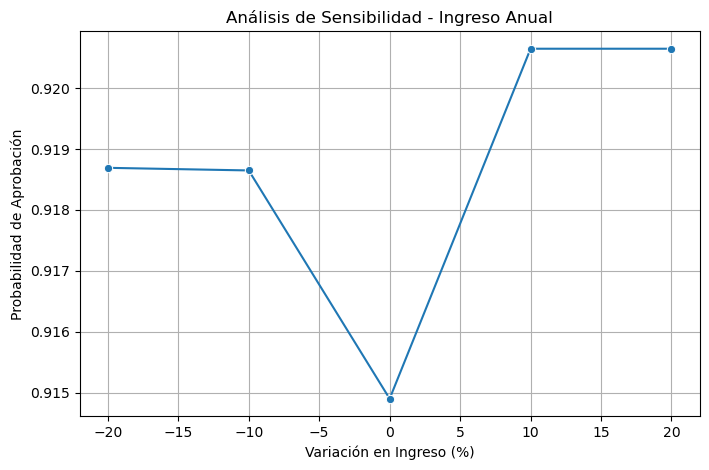

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Probability', data=sens_income, marker='o')
plt.title('Análisis de Sensibilidad - Ingreso Anual')
plt.xlabel('Variación en Ingreso (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()


### Sensibilidad al Ingreso Anual

El modelo muestra una relación positiva entre el ingreso anual y la probabilidad de aprobación. Sin embargo, el impacto marginal es moderado, indicando que el ingreso actúa como una variable de soporte y no como el principal driver de decisión.

## Sensibilidad al Monto del Préstamo

In [9]:
sens_loan = sensitivity_analysis(rf_clf, sample, 'loan_amount')
sens_loan

,Variation (%),Original Value,New Value,Original Probability,New Probability,Probability Change (%)
0,-20.0,1.633052,1.306441,0.9149,0.911563,-3.337348e-01
1,-10.0,1.633052,1.469747,0.9149,0.911170,-3.730747e-01
2,0.0,1.633052,1.633052,0.9149,0.914900,1.110223e-14
3,10.0,1.633052,1.796357,0.9149,0.914236,-6.643940e-02
4,20.0,1.633052,1.959662,0.9149,0.914418,-4.820411e-02


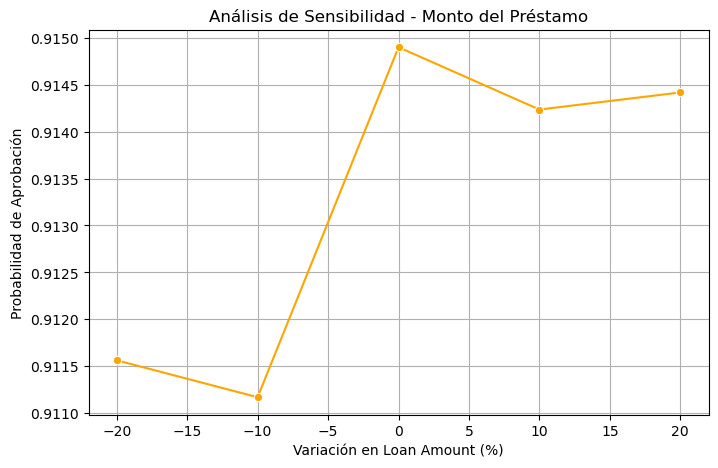

In [10]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Probability', data=sens_loan, marker='o', color='orange')
plt.title('Análisis de Sensibilidad - Monto del Préstamo')
plt.xlabel('Variación en Loan Amount (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()


Aumentos en el monto del préstamo reducen la probabilidad de aprobación, reflejando un mayor riesgo asumido por la entidad. El modelo penaliza incrementos de exposición, alineado con políticas prudenciales de crédito.

## Sensibilidad al CIBIL Score

In [12]:
sens_cibil = sensitivity_analysis(rf_clf, sample, 'cibil_score')
sens_cibil

,Variation (%),Original Value,New Value,Original Probability,New Probability,Probability Change (%)
0,-20.0,1.032792,0.826234,0.9149,0.914915,0.001429
1,-10.0,1.032792,0.929513,0.9149,0.913523,-0.137700
2,0.0,1.032792,1.032792,0.9149,0.914900,0.000000
3,10.0,1.032792,1.136072,0.9149,0.914909,0.000880
4,20.0,1.032792,1.239351,0.9149,0.914909,0.000880


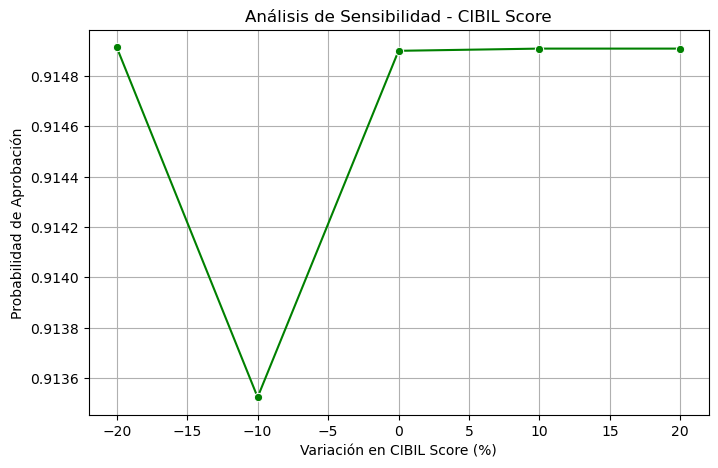

In [13]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Probability', data=sens_cibil, marker='o', color='green')
plt.title('Análisis de Sensibilidad - CIBIL Score')
plt.xlabel('Variación en CIBIL Score (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()

El CIBIL Score presenta la mayor sensibilidad marginal. Pequeñas variaciones generan cambios abruptos en la probabilidad de aprobación, confirmando que el modelo prioriza el historial crediticio como principal señal de riesgo.

## Conclusiones del Análisis de Sensibilidad

- El modelo es altamente sensible al score crediticio, confirmando su rol estructural en la decisión.
- Variables financieras como ingreso y monto del préstamo influyen de manera secundaria.
- El comportamiento observado es consistente con modelos reales de credit scoring utilizados en banca.
- El análisis refuerza la interpretabilidad y robustez del modelo para entornos regulatorios.
